# ERCOT Implied Settlement Research

Interactive research notebook for exploring ERCOT front-hour implied settlement pricing and market making signal quality.

**Data required:** LMP5 CSV (5-min RT LMP) and SPP15 CSV (15-min settlement prices) for a single hub and date.

**Cell order:**
Load Data → Replay Engine → Bid/Offer Parameters → Signal Analysis → Parameter Optimization → Adverse Fill Simulation (Hour) → Adverse Fill Simulation (Day) → ML Signal Filter → Out-of-Sample Validation

## 1. Setup
Imports and helper functions. Run once per session.

In [1]:
import sys
import itertools
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

from research.ercot.settlement_engine import SettlementEngine
from run_settlement_test_data import load_and_merge_events

print("Setup complete.")

Setup complete.


## 2. Load Data

Point `LMP5_CSV` and `SPP15_CSV` at your input files and set `HUB` to filter.

The loader (`load_and_merge_events`) handles column name inference, timezone parsing, and chronological merging — the same logic used by the CLI command.

In [2]:
# --- File paths: adjust these ---
LMP5_CSV  = r"C:\Users\kylek\Downloads\ercot_north_lmp5_20260101.csv"
SPP15_CSV = r"C:\Users\kylek\Downloads\ercot_north_spp15_20260101.csv"
HUB       = "HB_NORTH"

events = load_and_merge_events(LMP5_CSV, SPP15_CSV, hub_filter=HUB)

lmp_events  = [(ts, k, p) for ts, k, p in events if k == "lmp"]
spp_events  = [(ts, k, p) for ts, k, p in events if k == "spp15"]

print(f"Hub           : {HUB}")
print(f"Total events  : {len(events)}")
print(f"  LMP events  : {len(lmp_events)}")
print(f"  SPP15 events: {len(spp_events)}")
print(f"Date range    : {events[0][0].date()} -> {events[-1][0].date()}")

# Quick preview of raw data as DataFrames
lmp_df = pd.DataFrame([
    {"timestamp_utc": ts, "lmp": p["lmp"], "hour_ending": p["hour_ending"]}
    for ts, k, p in lmp_events
]).set_index("timestamp_utc")

spp_df = pd.DataFrame([
    {"timestamp_utc": ts, "spp15": p["spp15"], "hour_ending": p["hour_ending"], "interval_num": p["interval_num"]}
    for ts, k, p in spp_events
]).set_index("timestamp_utc")

print("\nLMP preview:")
display(lmp_df.head())
print("\nSPP15 preview:")
display(spp_df.head())

Hub           : HB_NORTH
Total events  : 35711
  LMP events  : 26884
  SPP15 events: 8827
Date range    : 2026-01-01 -> 2026-04-03

LMP preview:


,lmp,hour_ending
timestamp_utc,,
2026-01-01 06:00:17+00:00,17.98,24
2026-01-01 06:05:15+00:00,18.05,1
2026-01-01 06:10:17+00:00,17.89,1
2026-01-01 06:15:14+00:00,17.77,1
2026-01-01 06:20:15+00:00,17.62,1



SPP15 preview:


,spp15,hour_ending,interval_num
timestamp_utc,,,
2026-01-01 06:15:00+00:00,17.98,1,1
2026-01-01 06:30:00+00:00,17.66,1,2
2026-01-01 06:45:00+00:00,17.84,1,3
2026-01-01 07:00:00+00:00,18.08,1,4
2026-01-01 07:15:00+00:00,18.65,2,1


## 3. Raw Price Chart

LMP5 and SPP15 prices plotted together. Useful sanity check before replaying the engine.

C:\Users\kylek\AppData\Local\Temp\ipykernel_38080\1787501654.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


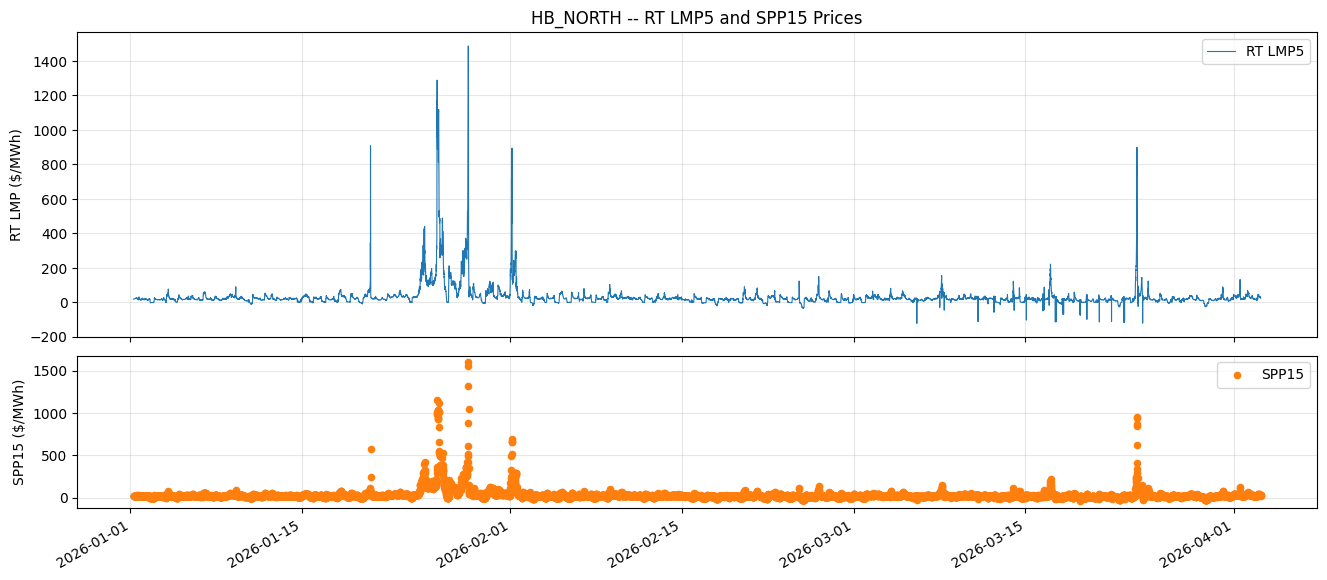

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})

ax_lmp, ax_spp = axes

ax_lmp.plot(lmp_df.index, lmp_df["lmp"], color="#1f77b4", linewidth=0.8, label="RT LMP5")
ax_spp.scatter(spp_df.index, spp_df["spp15"], color="#ff7f0e", s=20, label="SPP15", zorder=3)

ax_lmp.set_ylabel("RT LMP ($/MWh)")
ax_lmp.set_title(f"{HUB} -- RT LMP5 and SPP15 Prices")
ax_lmp.grid(True, alpha=0.3)
ax_lmp.legend()

ax_spp.set_ylabel("SPP15 ($/MWh)")
ax_spp.grid(True, alpha=0.3)
ax_spp.legend()

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 4. Bid/Offer Parameters

These are the tunable parameters that control how bids and offers are generated from the implied settlement.

| Parameter | Description |
|---|---|
| `BASE_SPREAD_PCT` | Half-spread applied each side of implied when all 4 SPP15s are confirmed |
| `SPREAD_MULTIPLIER_MAX` | Multiplier applied to spread when 0 SPP15s are confirmed (widest point) |
| `SPP_HOLD_MS` | After a mid-hour SPP15 confirm, wait up to this many ms for next LMP before publishing |
| `MAX_SPREAD_PCT` | Maximum allowed total spread as % of midpoint |
| `MAX_SPREAD_ABS` | Minimum floor on the total spread cap in $/MWh |
| `MAX_POSITION` | Hard inventory cap in MWh |
| `QUOTE_SIZE` | Normal quote size in MWh per side |

Adjust these and re-run sections 5+ to explore the effect on signal quality.

In [15]:
# --- Tunable parameters ---
BASE_SPREAD_PCT       = 0.02    # half-spread at 4/4 SPP15s confirmed
SPREAD_MULTIPLIER_MAX = 7.0    # spread multiplier at 0/4 SPP15s confirmed
SPP_HOLD_MS           = 25_000  # ms to hold publish after mid-hour SPP15 confirmation
MAX_SPREAD_PCT        = 0.20   # maximum allowed total spread as % of midpoint
MAX_SPREAD_ABS        = 8.0    # maximum allowed total spread in $/MWh
MAX_POSITION          = 100     # hard inventory cap in MWh
QUOTE_SIZE            = 10     # normal quote size in MWh per side

N_INTERVALS = 4


def spread_multiplier(confirmed_spp_count):
    """Linear scale from SPREAD_MULTIPLIER_MAX (0 confirmed) down to 1.0 (4 confirmed)."""
    unfilled = N_INTERVALS - min(max(confirmed_spp_count, 0), N_INTERVALS)
    return 1.0 + (SPREAD_MULTIPLIER_MAX - 1.0) * (unfilled / N_INTERVALS)


def bid_offer_from_implied(implied, confirmed_spp_count):
    """Return (bid, offer) around implied settlement with cap applied."""
    mult     = spread_multiplier(confirmed_spp_count)
    half_pct = BASE_SPREAD_PCT * mult
    bid      = implied * (1 - half_pct)
    offer    = implied * (1 + half_pct)
    mid      = (bid + offer) / 2
    max_total_spread = max(MAX_SPREAD_PCT * mid, MAX_SPREAD_ABS)
    if (offer - bid) > max_total_spread:
        half_dollar = max_total_spread / 2
        bid   = round(mid - half_dollar, 4)
        offer = round(mid + half_dollar, 4)
    else:
        bid   = round(bid, 4)
        offer = round(offer, 4)
    return bid, offer


# Show the spread schedule for the current parameters
print(f"BASE_SPREAD_PCT       : {BASE_SPREAD_PCT:.1%}")
print(f"SPREAD_MULTIPLIER_MAX : {SPREAD_MULTIPLIER_MAX}x")
print(f"SPP_HOLD_MS           : {SPP_HOLD_MS:,} ms ({SPP_HOLD_MS/1000:.1f}s)")
print(f"MAX_SPREAD_PCT        : {MAX_SPREAD_PCT:.0%} of mid")
print(f"MAX_SPREAD_ABS        : ${MAX_SPREAD_ABS:.2f}")
print(f"MAX_POSITION          : {MAX_POSITION} MWh")
print(f"QUOTE_SIZE            : {QUOTE_SIZE} MWh per side")
print()
print("Spread schedule (at implied = $50):")
print(f"  {'SPP15s confirmed':<20} {'Mult':>6} {'Half-spread':>12} {'Bid':>8} {'Offer':>8}")
for n in range(5):
    mult = spread_multiplier(n)
    bid, offer = bid_offer_from_implied(50.0, n)
    print(f"  {n}/4 confirmed        {mult:>6.2f}x   {BASE_SPREAD_PCT*mult:>10.1%}   {bid:>8.4f}  {offer:>8.4f}")

BASE_SPREAD_PCT       : 2.0%
SPREAD_MULTIPLIER_MAX : 7.0x
SPP_HOLD_MS           : 25,000 ms (25.0s)
MAX_SPREAD_PCT        : 20% of mid
MAX_SPREAD_ABS        : $8.00
MAX_POSITION          : 100 MWh
QUOTE_SIZE            : 10 MWh per side

Spread schedule (at implied = $50):
  SPP15s confirmed       Mult  Half-spread      Bid    Offer
  0/4 confirmed          7.00x        14.0%    45.0000   55.0000
  1/4 confirmed          5.50x        11.0%    45.0000   55.0000
  2/4 confirmed          4.00x         8.0%    46.0000   54.0000
  3/4 confirmed          2.50x         5.0%    47.5000   52.5000
  4/4 confirmed          1.00x         2.0%    49.0000   51.0000


## 5. Replay Engine -- Build Orders DataFrame

Replays the full event stream through the settlement engine using the parameters set in section 4.
Produces a row for every bid/offer update, mirroring what the CLI command writes to CSV.

Output: `orders_df` -- one row per published update with columns:
`timestamp_utc, hour_ending, intervals_realized, implied_settlement, bid, offer, spread_pct, projection_source`

In [16]:
def replay_events(events, base_spread_pct, spread_mult_max, spp_hold_ms,
                  max_spread_pct, max_spread_abs):
    """
    Replay the event stream and return a DataFrame of published bid/offer rows.
    Events are grouped by settlement_date so each day gets a fresh engine,
    preventing a finalized hour on day N from blocking the same hour on day N+1.
    """
    rows = []

    def _bid_offer(implied, confirmed_spp_count):
        unfilled = N_INTERVALS - min(max(confirmed_spp_count, 0), N_INTERVALS)
        mult     = 1.0 + (spread_mult_max - 1.0) * (unfilled / N_INTERVALS)
        half_pct = base_spread_pct * mult
        bid      = implied * (1 - half_pct)
        offer    = implied * (1 + half_pct)
        mid      = (bid + offer) / 2
        max_total_spread = max(max_spread_pct * mid, max_spread_abs)
        if (offer - bid) > max_total_spread:
            half_dollar = max_total_spread / 2
            bid   = round(mid - half_dollar, 4)
            offer = round(mid + half_dollar, 4)
        else:
            bid   = round(bid, 4)
            offer = round(offer, 4)
        return bid, offer

    def _publish(estimate, hub, hour_ending):
        bid, offer = _bid_offer(estimate.implied_settlement, estimate.intervals_realized)
        rows.append({
            "timestamp_utc":      estimate.timestamp,
            "hour_ending":        hour_ending,
            "intervals_realized": estimate.intervals_realized,
            "implied_settlement": estimate.implied_settlement,
            "bid":                bid,
            "offer":              offer,
            "spread_pct":         round((offer - bid) / estimate.implied_settlement, 6)
                                  if estimate.implied_settlement != 0 else None,
            "projection_source":  estimate.projection_source,
        })

    # Group by settlement_date; each day gets a fresh SettlementEngine
    from itertools import groupby
    key_fn = lambda ev: ev[2]["settlement_date"]
    for settlement_date, day_events in groupby(sorted(events, key=key_fn), key=key_fn):
        day_events = sorted(day_events, key=lambda ev: (ev[0], 0 if ev[1] == "lmp" else 1))
        engine = SettlementEngine(hubs=[HUB])
        held   = {}

        for ev in day_events:
            ts, kind, payload = ev
            hub         = payload["hub"]
            hour_ending = payload["hour_ending"]
            key         = (hub, hour_ending)

            if kind == "lmp" and key in held:
                result = engine.update_rt_lmp(hub=hub, hour_ending=hour_ending,
                                              lmp=payload["lmp"], as_of=payload["as_of"])
                if result is not None:
                    _publish(result, hub, hour_ending)
                del held[key]
                continue

            for (h, he), info in list(held.items()):
                if ts >= info["deadline"]:
                    est = engine.latest_estimate(h, he)
                    if est is not None:
                        _publish(est, h, he)
                    del held[(h, he)]

            if kind == "lmp":
                result = engine.update_rt_lmp(hub=hub, hour_ending=hour_ending,
                                              lmp=payload["lmp"], as_of=payload["as_of"])
                if result is not None:
                    _publish(result, hub, hour_ending)
            else:
                try:
                    result = engine.confirm_spp15(hub=hub, hour_ending=hour_ending,
                                                  interval_num=payload["interval_num"],
                                                  spp15=payload["spp15"],
                                                  confirmed_at=payload["confirmed_at"])
                except ValueError:
                    result = None
                if result is not None:
                    if result.intervals_remaining == 0:
                        _publish(result, hub, hour_ending)
                    else:
                        held[key] = {"deadline": ts + timedelta(milliseconds=spp_hold_ms)}

        for (h, he), info in held.items():
            est = engine.latest_estimate(h, he)
            if est is not None:
                _publish(est, h, he)

    df = pd.DataFrame(rows)
    if not df.empty:
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
        df = df.sort_values("timestamp_utc").reset_index(drop=True)
    return df


orders_df = replay_events(events, BASE_SPREAD_PCT, SPREAD_MULTIPLIER_MAX, SPP_HOLD_MS,
                          MAX_SPREAD_PCT, MAX_SPREAD_ABS)

print(f"Published rows    : {len(orders_df)}")
print(f"Hours covered     : {sorted(orders_df['hour_ending'].unique())}")
print(f"Projection sources:")
print(orders_df["projection_source"].value_counts().to_string())
print()
display(orders_df.head(10))

Published rows    : 26885
Hours covered     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Projection sources:
projection_source
rt_lmp_projection    24680
spp15_complete        2205



,timestamp_utc,hour_ending,intervals_realized,implied_settlement,bid,offer,spread_pct,projection_source
0,2026-01-01 06:00:17+00:00,24,0,17.9800,15.4628,20.4972,0.280000,rt_lmp_projection
1,2026-01-01 06:05:15+00:00,1,0,18.0500,15.5230,20.5770,0.280000,rt_lmp_projection
2,2026-01-01 06:10:17+00:00,1,0,17.8900,15.3854,20.3946,0.280000,rt_lmp_projection
3,2026-01-01 06:15:14+00:00,1,1,17.8225,15.8620,19.7830,0.220003,rt_lmp_projection
4,2026-01-01 06:20:15+00:00,1,1,17.7100,15.7619,19.6581,0.220000,rt_lmp_projection
5,2026-01-01 06:25:14+00:00,1,1,17.6650,15.7218,19.6082,0.220006,rt_lmp_projection
6,2026-01-01 06:30:14+00:00,1,2,17.7700,16.3484,19.1916,0.160000,rt_lmp_projection
7,2026-01-01 06:35:14+00:00,1,2,17.7850,16.3622,19.2078,0.160000,rt_lmp_projection
8,2026-01-01 06:40:15+00:00,1,2,17.9450,16.5094,19.3806,0.160000,rt_lmp_projection
9,2026-01-01 06:45:14+00:00,1,3,17.8750,16.9812,18.7688,0.100006,rt_lmp_projection


## 6. Signal Overlay -- Implied Settlement + Bid/Offer Chart

Visualizes implied settlement, bids, and offers for a selected hour ending and date.
SPP15 confirmation events are marked as vertical dashed lines.
Adjust `PLOT_HOUR` and `PLOT_DATE` to inspect any hour.

Plotting HE10 on 2026-03-26 -- 12 update rows, 4 SPP15 confirmations


C:\Users\kylek\AppData\Local\Temp\ipykernel_38080\2943954301.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


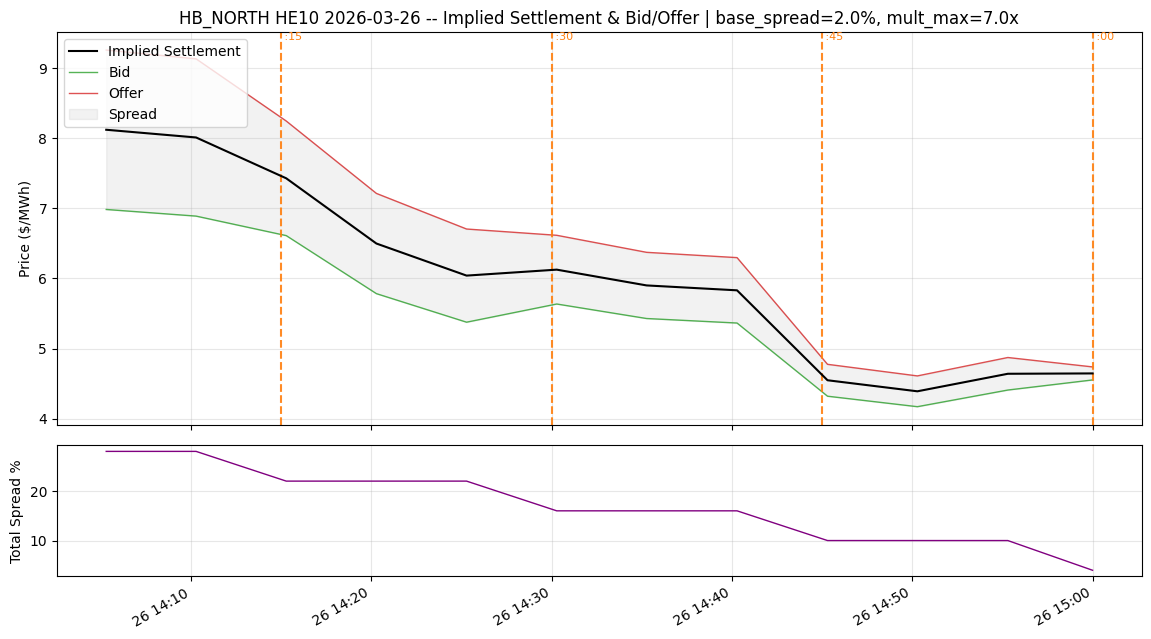

Final settlement: 4.6450 $/MWh


In [17]:
# --- Select which hour and date to inspect ---
# PLOT_HOUR = orders_df["hour_ending"].iloc[0]
# PLOT_DATE = orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date.iloc[0]
PLOT_HOUR = 10   # hour ending to inspect (1–24)
PLOT_DATE = pd.Timestamp("2026-03-26").date()

hour_df = orders_df[
    (orders_df["hour_ending"] == PLOT_HOUR) &
    (orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date == PLOT_DATE)
].copy()

spp_hour = spp_df[
    (spp_df["hour_ending"] == PLOT_HOUR) &
    (spp_df.index.tz_convert("America/Chicago").date == PLOT_DATE)
]

print(f"Plotting HE{PLOT_HOUR} on {PLOT_DATE} -- {len(hour_df)} update rows, {len(spp_hour)} SPP15 confirmations")

if hour_df.empty:
    print("No data for this hour/date combination. Adjust PLOT_HOUR or PLOT_DATE.")
else:
    interval_labels = {1: ":15", 2: ":30", 3: ":45", 4: ":00"}

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})
    ax_price, ax_spread = axes

    ax_price.plot(hour_df["timestamp_utc"], hour_df["implied_settlement"],
                  color="black", linewidth=1.5, label="Implied Settlement", zorder=3)
    ax_price.plot(hour_df["timestamp_utc"], hour_df["bid"],
                  color="#2ca02c", linewidth=1.0, alpha=0.8, label="Bid")
    ax_price.plot(hour_df["timestamp_utc"], hour_df["offer"],
                  color="#d62728", linewidth=1.0, alpha=0.8, label="Offer")
    ax_price.fill_between(hour_df["timestamp_utc"], hour_df["bid"], hour_df["offer"],
                          alpha=0.10, color="gray", label="Spread")

    for _, spp_row in spp_hour.iterrows():
        ax_price.axvline(spp_row.name, color="#ff7f0e", linewidth=1.5, linestyle="--", alpha=0.9)
        ax_price.text(spp_row.name, ax_price.get_ylim()[1],
                      f" {interval_labels[spp_row['interval_num']]}",
                      fontsize=8, color="#ff7f0e", va="top")

    ax_price.set_ylabel("Price ($/MWh)")
    ax_price.set_title(f"{HUB} HE{PLOT_HOUR} {PLOT_DATE} -- Implied Settlement & Bid/Offer | "
                       f"base_spread={BASE_SPREAD_PCT:.1%}, mult_max={SPREAD_MULTIPLIER_MAX}x")
    ax_price.legend(loc="upper left")
    ax_price.grid(True, alpha=0.3)

    ax_spread.plot(hour_df["timestamp_utc"], hour_df["spread_pct"] * 100,
                   color="purple", linewidth=1.0)
    ax_spread.set_ylabel("Total Spread %")
    ax_spread.grid(True, alpha=0.3)

    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()

    finals = hour_df[hour_df["intervals_realized"] == 4]["implied_settlement"]
    if not finals.empty:
        print(f"Final settlement: {finals.iloc[-1]:.4f} $/MWh")
    else:
        print("Final settlement: not yet confirmed in this data slice")

## 7. Adverse Fill Simulation -- Single Hour

Simulates fills against the published bid/offer using the RT LMP as the aggressor price.

**Fill logic (adverse -- worst case for the market maker):**
- If RT LMP **<= bid** at a given update -> a sell aggressor hits our bid -> we BUY at our bid price
- If RT LMP **>= offer** at a given update -> a buy aggressor lifts our offer -> we SELL at our offer price

This is conservative: it assumes every possible adverse fill occurs, giving a lower bound on PnL.
Open inventory at hour end is marked to the final SPP15 average (bounded settlement).
No transaction costs are modeled.

Adjust `SIM_HOUR` and `SIM_DATE` to inspect any hour.

=== Adverse Fill Simulation: HE10 on 2026-03-26 ===
  Final settlement : 4.6450 $/MWh
  Total fills      : 9
  Total PnL        : $32.31
  Peak position    : 90 MWh
  Final position   : -90 MWh



,timestamp_utc,side,fill_price,quantity,position,lmp,implied,intervals,final_settlement,pnl
0,2026-03-26 14:20:17+00:00,SELL,5.7828,10,-10,5.76,6.4975,1,4.645,11.378
1,2026-03-26 14:25:17+00:00,SELL,5.3756,10,-20,5.15,6.0400,1,4.645,7.306
2,2026-03-26 14:30:17+00:00,SELL,5.6350,10,-30,4.57,6.1250,2,4.645,9.900
3,2026-03-26 14:35:16+00:00,SELL,5.4280,10,-40,4.12,5.9000,2,4.645,7.830
4,2026-03-26 14:40:17+00:00,SELL,5.3636,10,-50,3.98,5.8300,2,4.645,7.186
5,2026-03-26 14:45:18+00:00,SELL,4.3201,10,-60,-1.72,4.5475,3,4.645,-3.249
6,2026-03-26 14:50:17+00:00,SELL,4.1705,10,-70,-2.35,4.3900,3,4.645,-4.745
7,2026-03-26 14:55:18+00:00,SELL,4.4080,10,-80,-1.35,4.6400,3,4.645,-2.370
8,2026-03-26 15:00:00+00:00,SELL,4.5521,10,-90,-1.35,4.6450,4,4.645,-0.929


C:\Users\kylek\AppData\Local\Temp\ipykernel_38080\3750699826.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


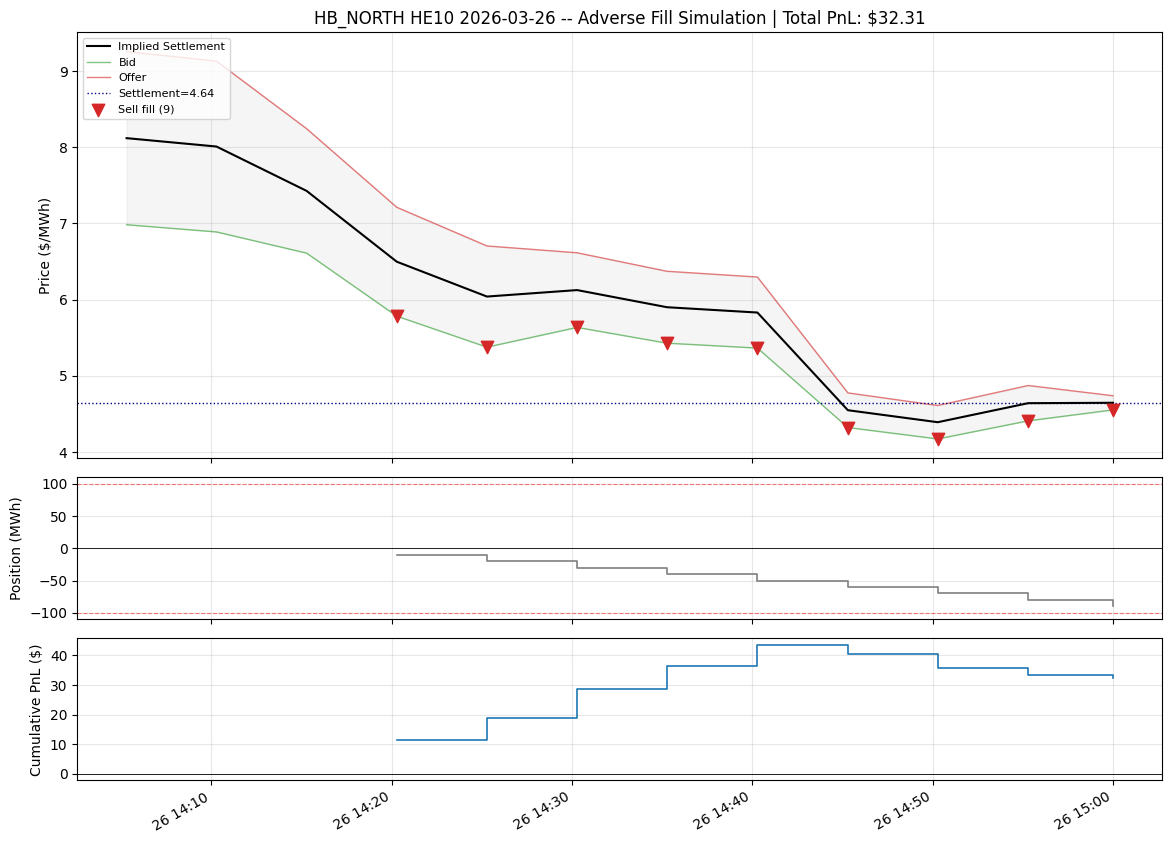

In [18]:
SIM_HOUR = PLOT_HOUR
SIM_DATE = PLOT_DATE


def simulate_hour(orders_df, lmp_df, hour_ending, sim_date, max_position, quote_size):
    """
    Simulate adverse fills for a single hour.

    Returns
    -------
    fills : list[dict]   One entry per simulated fill.
    final_settlement : float or None
    """
    hour_df = orders_df[
        (orders_df["hour_ending"] == hour_ending) &
        (orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date == sim_date)
    ].copy().sort_values("timestamp_utc")

    if hour_df.empty:
        return [], None

    final_rows = hour_df[hour_df["intervals_realized"] == 4]
    final_settlement = final_rows["implied_settlement"].iloc[-1] if not final_rows.empty else None

    # Align nearest prior LMP to each quote row
    lmp_reset = lmp_df[["lmp"]].reset_index().sort_values("timestamp_utc")
    hour_df = pd.merge_asof(
        hour_df.sort_values("timestamp_utc"),
        lmp_reset.rename(columns={"lmp": "lmp_at_quote"}),
        on="timestamp_utc",
        direction="backward",
    )

    position = 0
    fills    = []

    for _, row in hour_df.iterrows():
        lmp   = row["lmp_at_quote"]
        bid   = row["bid"]
        offer = row["offer"]
        ts    = row["timestamp_utc"]

        if pd.isna(lmp):
            continue

        if lmp >= offer and position < max_position:
            fill_qty = min(quote_size, max_position - position)
            if fill_qty > 0:
                position += fill_qty
                fills.append({
                    "timestamp_utc": ts,
                    "side":          "BUY",
                    "fill_price":    offer,
                    "quantity":      fill_qty,
                    "position":      position,
                    "lmp":           lmp,
                    "implied":       row["implied_settlement"],
                    "intervals":     row["intervals_realized"],
                })

        elif lmp <= bid and position > -max_position:
            fill_qty = min(quote_size, max_position + position)
            if fill_qty > 0:
                position -= fill_qty
                fills.append({
                    "timestamp_utc": ts,
                    "side":          "SELL",
                    "fill_price":    bid,
                    "quantity":      fill_qty,
                    "position":      position,
                    "lmp":           lmp,
                    "implied":       row["implied_settlement"],
                    "intervals":     row["intervals_realized"],
                })

    return fills, final_settlement


def compute_pnl(fills, final_settlement):
    """Mark each fill to final settlement and compute PnL."""
    if not fills or final_settlement is None:
        return fills
    for f in fills:
        if f["side"] == "BUY":
            f["pnl"] = (final_settlement - f["fill_price"]) * f["quantity"]
        else:
            f["pnl"] = (f["fill_price"] - final_settlement) * f["quantity"]
        f["final_settlement"] = final_settlement
    return fills


# --- Run single-hour simulation ---
fills, final_settlement = simulate_hour(
    orders_df, lmp_df, SIM_HOUR, SIM_DATE, MAX_POSITION, QUOTE_SIZE
)
fills = compute_pnl(fills, final_settlement)
fills_df = pd.DataFrame(fills)

print(f"=== Adverse Fill Simulation: HE{SIM_HOUR} on {SIM_DATE} ===")
print(f"  Final settlement : {final_settlement:.4f} $/MWh" if final_settlement else "  Final settlement : not available")
print(f"  Total fills      : {len(fills_df)}")

if not fills_df.empty:
    total_pnl = fills_df["pnl"].sum()
    print(f"  Total PnL        : ${total_pnl:.2f}")
    print(f"  Peak position    : {fills_df['position'].abs().max()} MWh")
    print(f"  Final position   : {fills_df['position'].iloc[-1]} MWh")
    print()
    display(fills_df[[
        "timestamp_utc", "side", "fill_price", "quantity", "position",
        "lmp", "implied", "intervals", "final_settlement", "pnl"
    ]].round(4))

    # --- Chart ---
    hour_plot = orders_df[
        (orders_df["hour_ending"] == SIM_HOUR) &
        (orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date == SIM_DATE)
    ].copy()

    buys  = fills_df[fills_df["side"] == "BUY"]
    sells = fills_df[fills_df["side"] == "SELL"]

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1, 1], "hspace": 0.08})
    ax_price, ax_pos, ax_pnl = axes

    ax_price.plot(hour_plot["timestamp_utc"], hour_plot["implied_settlement"],
                  color="black", linewidth=1.5, label="Implied Settlement", zorder=3)
    ax_price.plot(hour_plot["timestamp_utc"], hour_plot["bid"],
                  color="#2ca02c", linewidth=1.0, alpha=0.6, label="Bid")
    ax_price.plot(hour_plot["timestamp_utc"], hour_plot["offer"],
                  color="#d62728", linewidth=1.0, alpha=0.6, label="Offer")
    ax_price.fill_between(hour_plot["timestamp_utc"], hour_plot["bid"], hour_plot["offer"],
                          alpha=0.08, color="gray")
    if final_settlement:
        ax_price.axhline(final_settlement, color="navy", linewidth=1.0,
                         linestyle=":", label=f"Settlement={final_settlement:.2f}")
    if not buys.empty:
        ax_price.scatter(buys["timestamp_utc"], buys["fill_price"],
                         marker="^", color="#2ca02c", s=80, zorder=5,
                         label=f"Buy fill ({len(buys)})")
    if not sells.empty:
        ax_price.scatter(sells["timestamp_utc"], sells["fill_price"],
                         marker="v", color="#d62728", s=80, zorder=5,
                         label=f"Sell fill ({len(sells)})")
    ax_price.set_ylabel("Price ($/MWh)")
    ax_price.set_title(f"{HUB} HE{SIM_HOUR} {SIM_DATE} -- Adverse Fill Simulation | "
                       f"Total PnL: ${total_pnl:.2f}")
    ax_price.legend(loc="upper left", fontsize=8)
    ax_price.grid(True, alpha=0.3)

    ax_pos.step(fills_df["timestamp_utc"], fills_df["position"],
                where="post", color="#7f7f7f", linewidth=1.2)
    ax_pos.axhline(0, color="black", linewidth=0.6)
    ax_pos.axhline(MAX_POSITION,  color="red", linewidth=0.8, linestyle="--", alpha=0.5)
    ax_pos.axhline(-MAX_POSITION, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
    ax_pos.set_ylabel("Position (MWh)")
    ax_pos.grid(True, alpha=0.3)

    ax_pnl.step(fills_df["timestamp_utc"], fills_df["pnl"].cumsum(),
                where="post", color="#1f77b4", linewidth=1.2)
    ax_pnl.axhline(0, color="black", linewidth=0.6)
    ax_pnl.set_ylabel("Cumulative PnL ($)")
    ax_pnl.grid(True, alpha=0.3)

    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("  No fills generated -- LMP never crossed bid or offer during this hour.")

## 8. Adverse Fill Simulation -- Full Day

Runs the adverse fill simulation across every hour in the dataset for a selected date.
Inventory and PnL reset at the start of each hour -- each hour is an independent contract.

Produces:
- Per-hour summary table (fills, peak position, PnL)
- Full-day cumulative PnL chart across all hours
- Per-fill inventory chart
- Per-hour PnL bar chart

Adjust `SIM_DATE_FULL` to run on any date in the dataset.

Running full-day simulation for 2026-03-26
Hours found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

=== Full Day Summary: 2026-03-26 ===
  Total PnL        : $-50.85
  Hours with fills : 23 / 24
  Profitable hours : 8
  Loss hours       : 15



,final_settlement,n_fills,n_buys,n_sells,peak_position,final_position,pnl
hour_ending,,,,,,,
1,12.8375,1,0,1,10,-10,-2.57
2,12.7100,2,0,2,20,-20,-10.04
3,13.1625,1,0,1,10,-10,-2.63
4,12.6475,2,2,0,20,20,-9.61
5,13.0850,1,1,0,10,10,-2.62
6,14.8375,2,0,2,20,-20,-10.98
7,17.6550,2,2,0,20,20,-14.41
8,16.9400,4,0,4,40,-40,-30.60
9,12.5725,5,0,5,50,-50,-65.51


C:\Users\kylek\AppData\Local\Temp\ipykernel_38080\219571636.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


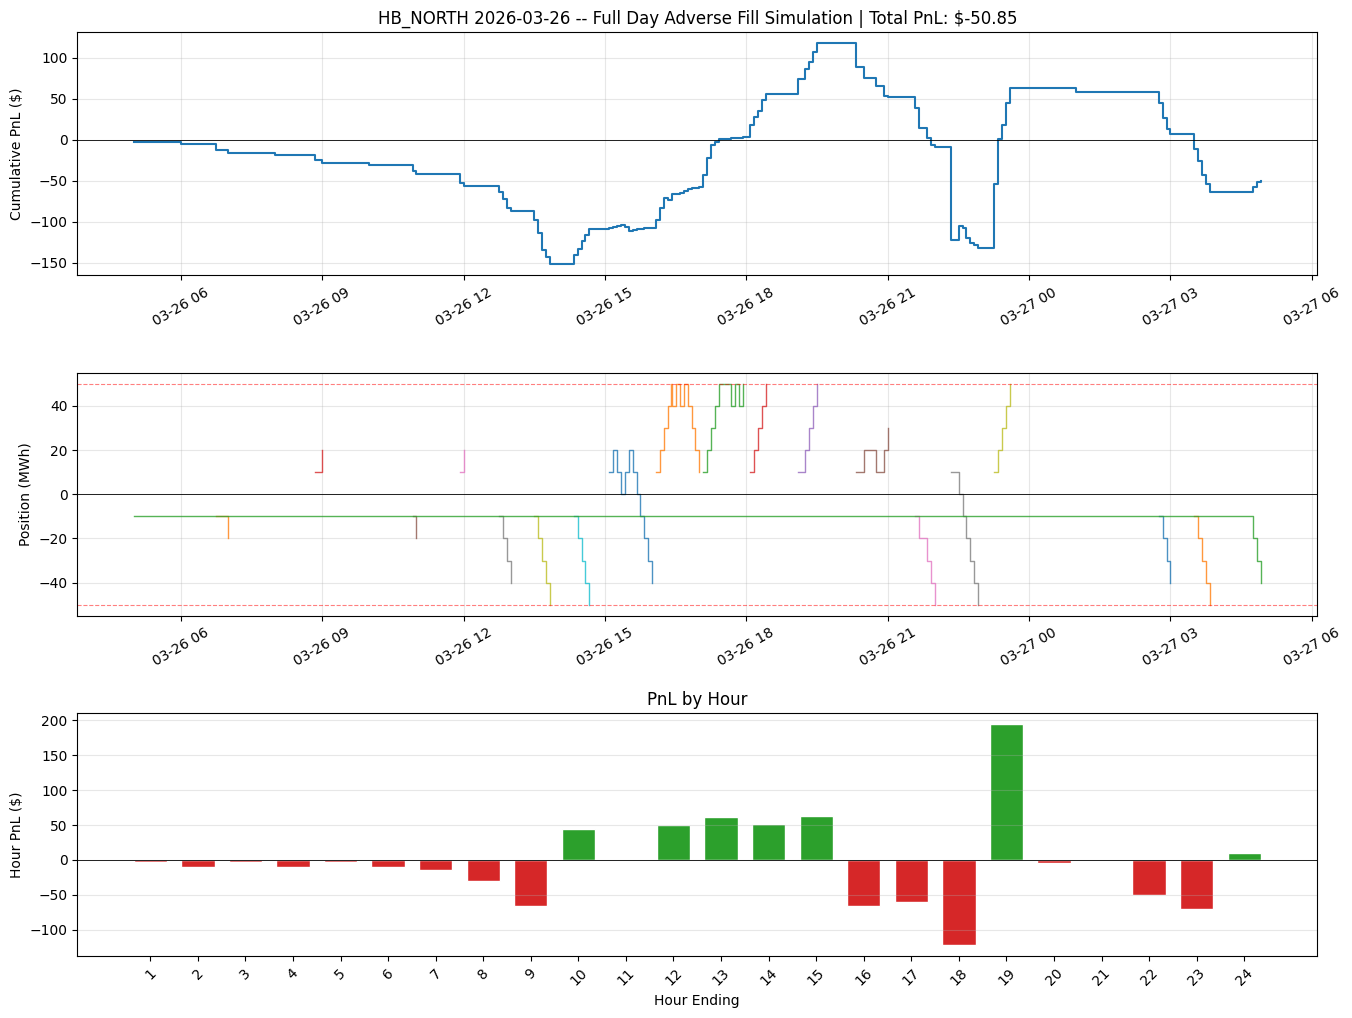

In [14]:
SIM_DATE_FULL = PLOT_DATE  # adjust to any date in your dataset

date_mask     = orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date == SIM_DATE_FULL
hours_in_date = sorted(orders_df[date_mask]["hour_ending"].unique())

print(f"Running full-day simulation for {SIM_DATE_FULL}")
print(f"Hours found: {hours_in_date}")
print()

day_summary = []
all_fills   = []

for he in hours_in_date:
    fills, final_settlement = simulate_hour(
        orders_df, lmp_df, he, SIM_DATE_FULL, MAX_POSITION, QUOTE_SIZE
    )
    fills = compute_pnl(fills, final_settlement)

    if fills:
        he_df = pd.DataFrame(fills)
        he_df["hour_ending"] = he
        all_fills.append(he_df)
        day_summary.append({
            "hour_ending":      he,
            "final_settlement": round(final_settlement, 4) if final_settlement else None,
            "n_fills":          len(fills),
            "n_buys":           sum(1 for f in fills if f["side"] == "BUY"),
            "n_sells":          sum(1 for f in fills if f["side"] == "SELL"),
            "peak_position":    he_df["position"].abs().max(),
            "final_position":   he_df["position"].iloc[-1],
            "pnl":              round(he_df["pnl"].sum(), 2),
        })
    else:
        day_summary.append({
            "hour_ending":      he,
            "final_settlement": round(final_settlement, 4) if final_settlement else None,
            "n_fills": 0, "n_buys": 0, "n_sells": 0,
            "peak_position": 0, "final_position": 0, "pnl": 0.0,
        })

summary_df    = pd.DataFrame(day_summary)
total_day_pnl = summary_df["pnl"].sum()

print(f"=== Full Day Summary: {SIM_DATE_FULL} ===")
print(f"  Total PnL        : ${total_day_pnl:.2f}")
print(f"  Hours with fills : {(summary_df['n_fills'] > 0).sum()} / {len(summary_df)}")
print(f"  Profitable hours : {(summary_df['pnl'] > 0).sum()}")
print(f"  Loss hours       : {(summary_df['pnl'] < 0).sum()}")
print()
display(summary_df.set_index("hour_ending"))

if all_fills:
    all_fills_df = pd.concat(all_fills, ignore_index=True).sort_values("timestamp_utc")

    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False,
                             gridspec_kw={"hspace": 0.4})
    ax_pnl, ax_pos, ax_bar = axes

    # Cumulative PnL across the full day
    ax_pnl.step(all_fills_df["timestamp_utc"], all_fills_df["pnl"].cumsum(),
                where="post", color="#1f77b4", linewidth=1.5)
    ax_pnl.axhline(0, color="black", linewidth=0.6)
    ax_pnl.set_ylabel("Cumulative PnL ($)")
    ax_pnl.set_title(f"{HUB} {SIM_DATE_FULL} -- Full Day Adverse Fill Simulation | "
                     f"Total PnL: ${total_day_pnl:.2f}")
    ax_pnl.grid(True, alpha=0.3)
    ax_pnl.xaxis.set_tick_params(rotation=30)

    # Per-fill position by hour (each hour resets to 0)
    for he in hours_in_date:
        he_fills = all_fills_df[all_fills_df["hour_ending"] == he]
        if not he_fills.empty:
            ax_pos.step(he_fills["timestamp_utc"], he_fills["position"],
                        where="post", linewidth=1.0, alpha=0.8, label=f"HE{he}")
    ax_pos.axhline(0, color="black", linewidth=0.6)
    ax_pos.axhline(MAX_POSITION,  color="red", linewidth=0.8, linestyle="--", alpha=0.5)
    ax_pos.axhline(-MAX_POSITION, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
    ax_pos.set_ylabel("Position (MWh)")
    ax_pos.grid(True, alpha=0.3)
    ax_pos.xaxis.set_tick_params(rotation=30)

    # Per-hour PnL bar chart
    colors = ["#2ca02c" if v >= 0 else "#d62728" for v in summary_df["pnl"]]
    ax_bar.bar(summary_df["hour_ending"].astype(str), summary_df["pnl"],
               color=colors, edgecolor="white", width=0.7)
    ax_bar.axhline(0, color="black", linewidth=0.6)
    ax_bar.set_ylabel("Hour PnL ($)")
    ax_bar.set_xlabel("Hour Ending")
    ax_bar.set_title("PnL by Hour")
    ax_bar.grid(True, axis="y", alpha=0.3)
    ax_bar.tick_params(axis="x", labelrotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("No fills generated for any hour on this date.")

## Date Range Adverse Fill Simulation

In [ ]:
# --- Date range simulation ---
# Set SIM_START and SIM_END to any dates within your dataset.
# Preset shortcuts are provided below — uncomment one or set manually.

SIM_START = pd.Timestamp("2026-01-01").date()
SIM_END   = pd.Timestamp("2026-04-03").date()

# --- Preset shortcuts (uncomment one) ---
# One week ending on the last date in the dataset:
# SIM_END   = orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date.max()
# SIM_START = SIM_END - pd.Timedelta(weeks=1)

# One month ending on the last date in the dataset:
# SIM_END   = orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date.max()
# SIM_START = SIM_END - pd.DateOffset(months=1)

# Full dataset range (default):
# SIM_START = orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date.min()
# SIM_END   = orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date.max()

# --- Find all (date, hour) combinations in range ---
ct_dates = orders_df["timestamp_utc"].dt.tz_convert("America/Chicago").dt.date
date_mask = (ct_dates >= SIM_START) & (ct_dates <= SIM_END)
date_hour_pairs = (
    orders_df[date_mask][["hour_ending"]]
    .assign(date=ct_dates[date_mask])
    .drop_duplicates()
    .sort_values(["date", "hour_ending"])
)

print(f"Date range    : {SIM_START} -> {SIM_END}")
print(f"Calendar days : {(SIM_END - SIM_START).days + 1}")
print(f"Hours to sim  : {len(date_hour_pairs)}")
print()

# --- Run simulation across all (date, hour) pairs ---
range_summary = []
range_fills   = []

for _, row in date_hour_pairs.iterrows():
    sim_date = row["date"]
    he       = row["hour_ending"]

    fills, final_settlement = simulate_hour(
        orders_df, lmp_df, he, sim_date, MAX_POSITION, QUOTE_SIZE
    )
    fills = compute_pnl(fills, final_settlement)

    if fills and final_settlement is not None:
        he_df = pd.DataFrame(fills)
        he_df["date"]        = sim_date
        he_df["hour_ending"] = he
        range_fills.append(he_df)
        range_summary.append({
            "date":             sim_date,
            "hour_ending":      he,
            "final_settlement": round(final_settlement, 4) if final_settlement else None,
            "n_fills":          len(fills),
            "n_buys":           sum(1 for f in fills if f["side"] == "BUY"),
            "n_sells":          sum(1 for f in fills if f["side"] == "SELL"),
            "peak_position":    he_df["position"].abs().max(),
            "final_position":   he_df["position"].iloc[-1],
            "pnl":              round(he_df["pnl"].sum(), 2),
        })
    else:
        range_summary.append({
            "date":             sim_date,
            "hour_ending":      he,
            "final_settlement": round(final_settlement, 4) if final_settlement else None,
            "n_fills": 0, "n_buys": 0, "n_sells": 0,
            "peak_position": 0, "final_position": 0, "pnl": 0.0,
        })

range_summary_df = pd.DataFrame(range_summary)
total_range_pnl  = range_summary_df["pnl"].sum()
n_hours          = len(range_summary_df)
n_with_fills     = (range_summary_df["n_fills"] > 0).sum()

print(f"=== Date Range Simulation: {SIM_START} -> {SIM_END} ===")
print(f"  Total PnL         : ${total_range_pnl:.2f}")
print(f"  Hours simulated   : {n_hours}")
print(f"  Hours with fills  : {n_with_fills}")
print(f"  Profitable hours  : {(range_summary_df['pnl'] > 0).sum()}")
print(f"  Loss hours        : {(range_summary_df['pnl'] < 0).sum()}")
print(f"  Avg PnL / hour    : ${range_summary_df['pnl'].mean():.2f}")
print(f"  Best hour         : ${range_summary_df['pnl'].max():.2f}")
print(f"  Worst hour        : ${range_summary_df['pnl'].min():.2f}")
print()

# Daily rollup
daily_pnl = range_summary_df.groupby("date")["pnl"].sum().reset_index()
daily_pnl["cumulative_pnl"] = daily_pnl["pnl"].cumsum()
print("Daily PnL summary:")
display(daily_pnl)

if range_fills:
    range_fills_df = pd.concat(range_fills, ignore_index=True).sort_values("timestamp_utc")

    fig, axes = plt.subplots(4, 1, figsize=(16, 16),
                             gridspec_kw={"hspace": 0.45})
    ax_cum, ax_daily, ax_dist, ax_pos = axes

    # --- Cumulative PnL over time ---
    ax_cum.plot(daily_pnl["date"], daily_pnl["cumulative_pnl"],
                color="#1f77b4", linewidth=1.5, marker="o", markersize=3)
    ax_cum.axhline(0, color="black", linewidth=0.6)
    ax_cum.fill_between(daily_pnl["date"], daily_pnl["cumulative_pnl"], 0,
                        where=daily_pnl["cumulative_pnl"] >= 0,
                        alpha=0.15, color="#2ca02c", label="Profitable")
    ax_cum.fill_between(daily_pnl["date"], daily_pnl["cumulative_pnl"], 0,
                        where=daily_pnl["cumulative_pnl"] < 0,
                        alpha=0.15, color="#d62728", label="Loss")
    ax_cum.set_ylabel("Cumulative PnL ($)")
    ax_cum.set_title(f"{HUB} {SIM_START} -> {SIM_END} -- Date Range Adverse Fill Simulation | "
                     f"Total PnL: ${total_range_pnl:.2f}")
    ax_cum.legend(fontsize=8)
    ax_cum.grid(True, alpha=0.3)
    ax_cum.tick_params(axis="x", labelrotation=30)

    # --- Daily PnL bar chart ---
    colors = ["#2ca02c" if v >= 0 else "#d62728" for v in daily_pnl["pnl"]]
    ax_daily.bar(daily_pnl["date"].astype(str), daily_pnl["pnl"],
                 color=colors, edgecolor="none", width=0.7)
    ax_daily.axhline(0, color="black", linewidth=0.6)
    ax_daily.set_ylabel("Daily PnL ($)")
    ax_daily.set_title("Daily PnL")
    ax_daily.grid(True, axis="y", alpha=0.3)
    ax_daily.tick_params(axis="x", labelrotation=45,
                         labelbottom=len(daily_pnl) <= 60)  # hide x labels if too many dates
    if len(daily_pnl) > 60:
        # Show only month boundaries
        month_starts = daily_pnl[daily_pnl["date"].apply(lambda d: d.day == 1)]
        ax_daily.set_xticks(month_starts.index)
        ax_daily.set_xticklabels(
            [str(d) for d in month_starts["date"]], rotation=30
        )

    # --- PnL distribution per hour ---
    ax_dist.hist(range_summary_df["pnl"], bins=40, color="#1f77b4",
                 edgecolor="white", alpha=0.8)
    ax_dist.axvline(0, color="black", linewidth=0.8)
    ax_dist.axvline(range_summary_df["pnl"].mean(), color="#ff7f0e",
                    linewidth=1.2, linestyle="--", label=f"Mean=${range_summary_df['pnl'].mean():.2f}")
    ax_dist.set_xlabel("PnL per Hour ($)")
    ax_dist.set_ylabel("Count")
    ax_dist.set_title("Distribution of PnL per Hour")
    ax_dist.legend(fontsize=8)
    ax_dist.grid(True, axis="y", alpha=0.3)

    # --- Peak position per hour (scatter by hour_ending) ---
    ax_pos.scatter(range_summary_df["hour_ending"],
                   range_summary_df["peak_position"],
                   alpha=0.4, s=15, color="#7f7f7f")
    # Overlay median per hour ending
    median_pos = range_summary_df.groupby("hour_ending")["peak_position"].median()
    ax_pos.plot(median_pos.index, median_pos.values,
                color="#d62728", linewidth=1.5, marker="o", markersize=4,
                label="Median peak position")
    ax_pos.axhline(MAX_POSITION, color="red", linewidth=0.8,
                   linestyle="--", alpha=0.5, label=f"Cap={MAX_POSITION}")
    ax_pos.set_xlabel("Hour Ending")
    ax_pos.set_ylabel("Peak Position (MWh)")
    ax_pos.set_title("Peak Position by Hour of Day")
    ax_pos.legend(fontsize=8)
    ax_pos.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No fills generated for any hour in this date range.")

Date range    : 2026-01-01 -> 2026-04-03
Calendar days : 93
Hours to sim  : 2209



KeyError: 'pnl'

## 9. Signal Quality Analysis

Evaluates how accurately the implied settlement at each update predicts the final hourly settlement.

Key metrics:
- **MAE** -- mean absolute error of implied vs final settlement
- **Error by intervals_realized** -- how much error remains at each stage of the hour
- **Spread coverage** -- what % of final settlement outcomes land inside the published bid/offer

In [ ]:
finals = (
    orders_df[orders_df["intervals_realized"] == 4]
    .groupby("hour_ending")["implied_settlement"]
    .last()
    .rename("final_settlement")
)

analysis_df = orders_df.join(finals, on="hour_ending")
analysis_df["error"]     = analysis_df["implied_settlement"] - analysis_df["final_settlement"]
analysis_df["abs_error"] = analysis_df["error"].abs()
analysis_df["within_spread"] = (
    (analysis_df["final_settlement"] >= analysis_df["bid"]) &
    (analysis_df["final_settlement"] <= analysis_df["offer"])
)
analysis_df = analysis_df.dropna(subset=["final_settlement"])

print("=== Overall Signal Quality ===")
print(f"  Hours with final settlement : {finals.shape[0]}")
print(f"  Total update rows analyzed  : {len(analysis_df)}")
print(f"  MAE (implied vs final)      : {analysis_df['abs_error'].mean():.4f} $/MWh")
print(f"  Spread coverage (final in [bid,offer]): {analysis_df['within_spread'].mean():.1%}")
print()
print("=== MAE by Intervals Confirmed ===")
mae_by_stage = analysis_df.groupby("intervals_realized")["abs_error"].agg(["mean", "median", "count"])
mae_by_stage.columns = ["MAE", "Median AE", "n_rows"]
display(mae_by_stage.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_mae, ax_cov = axes

mae_by_stage["MAE"].plot(kind="bar", ax=ax_mae, color="#1f77b4", edgecolor="white")
ax_mae.set_title("MAE of Implied vs Final Settlement\nby Intervals Confirmed")
ax_mae.set_xlabel("SPP15 Intervals Confirmed")
ax_mae.set_ylabel("MAE ($/MWh)")
ax_mae.set_xticklabels([f"{i}/4" for i in mae_by_stage.index], rotation=0)
ax_mae.grid(True, axis="y", alpha=0.3)

cov_by_stage = analysis_df.groupby("intervals_realized")["within_spread"].mean() * 100
cov_by_stage.plot(kind="bar", ax=ax_cov, color="#2ca02c", edgecolor="white")
ax_cov.axhline(100, color="gray", linestyle="--", linewidth=0.8)
ax_cov.set_title("Spread Coverage: % of Final Settlements\nInside Published Bid/Offer")
ax_cov.set_xlabel("SPP15 Intervals Confirmed")
ax_cov.set_ylabel("Coverage %")
ax_cov.set_xticklabels([f"{i}/4" for i in cov_by_stage.index], rotation=0)
ax_cov.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Feature Engineering

Builds ML-ready features from each published update row.

| Feature | Description |
|---|---|
| `intervals_realized` | How many SPP15s have been confirmed (0-4) |
| `spread_pct` | Published total spread as a fraction of implied |
| `implied_vs_lmp` | Implied settlement minus the last RT LMP at time of update |
| `implied_roll_5` | Implied settlement minus its 5-row rolling mean (momentum) |
| `implied_roll_std` | Rolling 5-row std of implied (local volatility of estimate) |
| `hour_normalized` | Hour ending normalized to [0, 1] |

**Label:** whether the final settlement was within the published bid/offer.

In [ ]:
PROFIT_THRESHOLD = 0.0

feat_df    = analysis_df.copy().sort_values("timestamp_utc").reset_index(drop=True)
lmp_indexed = lmp_df[["lmp"]].reset_index()

feat_df = pd.merge_asof(
    feat_df.sort_values("timestamp_utc"),
    lmp_indexed.sort_values("timestamp_utc").rename(columns={"lmp": "latest_lmp"}),
    on="timestamp_utc",
    direction="backward",
)

feat_df["implied_vs_lmp"]   = feat_df["implied_settlement"] - feat_df["latest_lmp"]
feat_df["implied_roll_5"]   = feat_df["implied_settlement"] - feat_df["implied_settlement"].rolling(5).mean()
feat_df["implied_roll_std"] = feat_df["implied_settlement"].rolling(5).std()
feat_df["hour_normalized"]  = feat_df["hour_ending"] / 24.0

feat_df["label"] = (
    (feat_df["final_settlement"] >= feat_df["bid"] + PROFIT_THRESHOLD) &
    (feat_df["final_settlement"] <= feat_df["offer"] - PROFIT_THRESHOLD)
).astype(int)

FEATURES = ["intervals_realized", "spread_pct", "implied_vs_lmp",
            "implied_roll_5", "implied_roll_std", "hour_normalized"]

ml_df = feat_df[FEATURES + ["label"]].dropna()

print(f"ML-ready rows : {len(ml_df)}")
print(f"Label distribution:")
print(ml_df["label"].value_counts().to_string())
display(ml_df.head())

## 11. Parameter Optimization

Grid search over `BASE_SPREAD_PCT` and `SPREAD_MULTIPLIER_MAX`, ranked by coverage then tightest spread.
Run on **in-sample data only**.

In [ ]:
BASE_SPREAD_PCTS       = [0.02, 0.03, 0.05, 0.07, 0.10]
SPREAD_MULTIPLIER_MAXS = [2.0, 3.0, 5.0, 7.0]

opt_results = []

for base_pct, mult_max in itertools.product(BASE_SPREAD_PCTS, SPREAD_MULTIPLIER_MAXS):
    df = replay_events(events, base_pct, mult_max, SPP_HOLD_MS, MAX_SPREAD_PCT, MAX_SPREAD_ABS)
    if df.empty:
        continue
    finals_local = (
        df[df["intervals_realized"] == 4]
        .groupby("hour_ending")["implied_settlement"]
        .last()
        .rename("final_settlement")
    )
    df = df.join(finals_local, on="hour_ending").dropna(subset=["final_settlement"])
    if df.empty:
        continue
    within = ((df["final_settlement"] >= df["bid"]) & (df["final_settlement"] <= df["offer"]))
    opt_results.append({
        "base_spread_pct":       base_pct,
        "spread_multiplier_max": mult_max,
        "coverage":              round(within.mean(), 4),
        "avg_spread_pct":        round(df["spread_pct"].mean(), 4),
        "n_rows":                len(df),
    })

opt_df = pd.DataFrame(opt_results).sort_values(["coverage", "avg_spread_pct"],
                                                ascending=[False, True])
print("Parameter optimization results (ranked by coverage, then tightest spread):")
display(opt_df.reset_index(drop=True))

## 12. Lock In Parameters

Once satisfied with the optimization results, run this cell to capture the chosen parameters.
The ML and out-of-sample cells read from `best_params`.

Update the values in section 4 to match your chosen values before running this cell.

In [ ]:
best_params = {
    "base_spread_pct":       BASE_SPREAD_PCT,
    "spread_multiplier_max": SPREAD_MULTIPLIER_MAX,
    "spp_hold_ms":           SPP_HOLD_MS,
    "max_spread_pct":        MAX_SPREAD_PCT,
    "max_spread_abs":        MAX_SPREAD_ABS,
}

print("Parameters locked in:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

## 13. ML -- Random Forest Signal Filter

Trains a binary classifier to predict whether a given published update will have the final settlement inside the spread.
Use `shuffle=False` -- test must always be in the future relative to training.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

_bp = best_params
orders_best = replay_events(events, _bp["base_spread_pct"], _bp["spread_multiplier_max"],
                            _bp["spp_hold_ms"], _bp["max_spread_pct"], _bp["max_spread_abs"])

finals_best = (
    orders_best[orders_best["intervals_realized"] == 4]
    .groupby("hour_ending")["implied_settlement"]
    .last()
    .rename("final_settlement")
)
feat_best = orders_best.join(finals_best, on="hour_ending").dropna(subset=["final_settlement"])
feat_best = pd.merge_asof(
    feat_best.sort_values("timestamp_utc"),
    lmp_indexed.sort_values("timestamp_utc").rename(columns={"lmp": "latest_lmp"}),
    on="timestamp_utc", direction="backward",
)
feat_best["implied_vs_lmp"]   = feat_best["implied_settlement"] - feat_best["latest_lmp"]
feat_best["implied_roll_5"]   = feat_best["implied_settlement"] - feat_best["implied_settlement"].rolling(5).mean()
feat_best["implied_roll_std"] = feat_best["implied_settlement"].rolling(5).std()
feat_best["hour_normalized"]  = feat_best["hour_ending"] / 24.0
feat_best["label"] = (
    (feat_best["final_settlement"] >= feat_best["bid"]) &
    (feat_best["final_settlement"] <= feat_best["offer"])
).astype(int)

ml_best = feat_best[FEATURES + ["label"]].dropna()
X = ml_best[FEATURES]
y = ml_best["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Classification report:")
print(classification_report(y_test, model.predict(X_test)))

importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nFeature importances:")
print(importance.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind="bar", ax=ax, color="#1f77b4", edgecolor="white")
ax.set_title("Random Forest Feature Importances")
ax.set_ylabel("Importance")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 14. Out-of-Sample Validation

Splits the event stream chronologically and validates that best_params hold up on unseen data.

- **In-sample** -- the first `IN_SAMPLE_FRAC` of events
- **Out-of-sample** -- the remainder (never used during optimization or ML)

**Never adjust parameters based on out-of-sample results.**

In [ ]:
IN_SAMPLE_FRAC = 0.7

split_idx  = int(len(events) * IN_SAMPLE_FRAC)
events_in  = events[:split_idx]
events_out = events[split_idx:]

print(f"In-sample    : {len(events_in)} events  ({events_in[0][0].date()} -> {events_in[-1][0].date()})")
print(f"Out-of-sample: {len(events_out)} events ({events_out[0][0].date()} -> {events_out[-1][0].date()})")

_bp = best_params

def _score(ev):
    df = replay_events(ev, _bp["base_spread_pct"], _bp["spread_multiplier_max"],
                       _bp["spp_hold_ms"], _bp["max_spread_pct"], _bp["max_spread_abs"])
    if df.empty:
        return None
    finals_loc = (
        df[df["intervals_realized"] == 4]
        .groupby("hour_ending")["implied_settlement"]
        .last()
        .rename("final_settlement")
    )
    df = df.join(finals_loc, on="hour_ending").dropna(subset=["final_settlement"])
    if df.empty:
        return None
    within = ((df["final_settlement"] >= df["bid"]) & (df["final_settlement"] <= df["offer"]))
    return {
        "n_rows":         len(df),
        "coverage":       round(within.mean(), 4),
        "avg_spread_pct": round(df["spread_pct"].mean(), 4),
        "mae":            round((df["implied_settlement"] - df["final_settlement"]).abs().mean(), 4),
    }

in_score  = _score(events_in)
oos_score = _score(events_out)

print()
print(f"{'Metric':<22} {'In-sample':>12} {'Out-of-sample':>15}")
print("-" * 52)
for k in ["coverage", "avg_spread_pct", "mae", "n_rows"]:
    iv = in_score[k]  if in_score  else "n/a"
    ov = oos_score[k] if oos_score else "n/a"
    print(f"  {k:<20} {str(iv):>12} {str(ov):>15}")

print()
if oos_score and in_score and oos_score["coverage"] >= in_score["coverage"] * 0.90:
    print("OUT-OF-SAMPLE: PASS -- coverage within 10% of in-sample. Parameters may generalize.")
else:
    print("OUT-OF-SAMPLE: FAIL -- coverage degraded meaningfully. Parameters may be overfit.")